# TC Track Diagnostics - Tracking Method Comparison

Focused notebook for comparing TempestExtremes tracking outputs across different tracking method sets (set1-set5).


In [1]:
import os
import sys
import subprocess
import re
from pathlib import Path

# PROJ data path — auto-resolved when running under the e3sm_analysis kernel
# (CONDA_PREFIX is set).  Hardcoded fallback only needed if kernel is not activated.
# This MUST be set before importing Cartopy/GDAL/PyProj or any package that
# transitively imports them; otherwise the environment variables may be
# applied too late to influence which native PROJ data actually gets loaded.
_proj_path = os.path.join(os.environ.get("CONDA_PREFIX", ""), "share", "proj")
if not os.path.exists(_proj_path):
    _proj_path = "/global/homes/z/zhan391/.conda/envs/e3sm_analysis/share/proj"
os.environ["PROJ_LIB"]  = _proj_path
os.environ["PROJ_DATA"] = _proj_path

import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from global_land_mask import globe

# Python interpreter for the tracking script.
# When the kernel IS e3sm_analysis, sys.executable is already correct.
PYTHON = sys.executable
print(f"PYTHON      : {PYTHON}")
print(f"CONDA_PREFIX: {os.environ.get('CONDA_PREFIX', '(not set — fallback paths used)')}")


from esp_lab.utils import mov_utils as mov
S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
HADISST2_DIAG_DIR = S2D_DIAG_ROOT / "HadISST2"
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

# Local helper modules used by this diagnostics notebook.
WORKFLOWS_DIR = Path("/global/homes/z/zhan391/code/ESP-Lab/workflows")
if str(WORKFLOWS_DIR) not in sys.path:
    sys.path.append(str(WORKFLOWS_DIR))
from tc_track_density import read_stitch_nodes_tracks


Warning 3: Cannot find header.dxf (GDAL_DATA is not defined)


PYTHON      : /global/homes/z/zhan391/.conda/envs/e3sm_analysis/bin/python
CONDA_PREFIX: /global/common/software/e3sm/anaconda_envs/base


Warning 3: Cannot find header.dxf (GDAL_DATA is not defined)


## Configuration — fill in ALL fields before running

Fields left as `None` will cause the **Validate** cell to raise an error.

In [2]:

# ------------------------------------------------------------------ #
#  PATHS
# ------------------------------------------------------------------ #

# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR


# TempestExtremes track and histogram files generated by the runner notebook.
TRACK_DIR    = Path("/global/cfs/cdirs/e3sm/S2S2D/post_process")

# Diagnostics written by this notebook.
OUTDIR       = E3SMLE_OUTDIR / "JRA55_FOSIRL" / "tc_track"

# Local helper modules used by this diagnostics notebook.
WORKFLOWS_DIR  = Path("/global/homes/z/zhan391/code/ESP-Lab/workflows")


# ------------------------------------------------------------------ #
#  CASES
# ------------------------------------------------------------------ #

case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"

years  = 1980
yeare  = 2018
yexcl  = None          # set to a year int to exclude, or None

init_months = [5, 11]  # May and November starts

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]

CASES = [
    f"{case_prefix}_{year}{init_month:02d}0100"
    for init_month in init_months
    for year in lead_years
]

print(f"Total cases: {len(CASES)}")
print("First few:", CASES[:3])
print("Last few: ", CASES[-3:])

# ------------------------------------------------------------------ #
#  ENSEMBLE / PARSET
# ------------------------------------------------------------------ #

case_nens = 10
members   = [f"EN{i:02d}" for i in range(case_nens)]
MEMBERS   = members
NENS      = None   # e.g. 3 for a quick test
PARSET    = "set3"

# Replace existing diagnostics NetCDF files when rerunning with a new method/setup.
OVERWRITE_OUTPUT = True

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"

# Mapping of parameter sets to descriptive professional names
PSET_DISPLAY_NAMES = {
    "set1": "Z200-Z500 (Height Anomaly)",
    "set2": "T200-T500 (Temp Anomaly)",
    "set3": "Z300-Z500 (Height Anomaly)",
    "set4": "T300-T500 (Temp Anomaly)",
    "set5": "T400 (Upper-level Temp)",
}


Total cases: 78
First few: ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1981050100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1982050100']
Last few:  ['WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2016110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2017110100', 'WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2018110100']


## Validate — run this before anything else

In [3]:
import subprocess, xarray as xr, matplotlib.pyplot as plt, cartopy.crs as ccrs

# ---- enforce all required fields are set ----
_required = {
    "CASES":        CASES,
    "TRACK_DIR":  TRACK_DIR,
    "OUTDIR":     OUTDIR,
    "WORKFLOWS_DIR":  WORKFLOWS_DIR,
    "MEMBERS":      MEMBERS,
    "PARSET":       PARSET,
    "OVERWRITE_OUTPUT": OVERWRITE_OUTPUT,
}
_missing = [k for k, v in _required.items() if v is None]
if _missing:
    raise ValueError(
        "The following required fields are still None — fill them in the Configuration cell:\n"
        + "\n".join(f"  {k}" for k in _missing)
    )

# ---- check diagnostics inputs/outputs ----
_errors = []
if not TRACK_DIR.is_dir():
    _errors.append(f"TRACK_DIR does not exist: {TRACK_DIR}")
if not WORKFLOWS_DIR.is_dir():
    _errors.append(f"WORKFLOWS_DIR does not exist: {WORKFLOWS_DIR}")

missing_case_dirs = [case for case in CASES if not (TRACK_DIR / case).is_dir()]
if missing_case_dirs:
    preview = ", ".join(missing_case_dirs[:5])
    more = "" if len(missing_case_dirs) <= 5 else f" ... ({len(missing_case_dirs) - 5} more)"
    _errors.append(f"Case directories not found under TRACK_DIR: {preview}{more}")

if _errors:
    raise FileNotFoundError("Path validation failed:\n" + "\n".join(_errors))

# ---- resolve member list from TRACK_DIR ----
_ref_case_dir = TRACK_DIR / CASES[0]
_all_members = sorted(
    p.name for p in _ref_case_dir.iterdir()
    if p.is_dir() and p.name.startswith("EN")
)
members_avail = list(MEMBERS) if MEMBERS else _all_members
if not members_avail:
    raise ValueError(f"No EN* member directories found in {_ref_case_dir}")
if NENS is not None:
    members_avail = members_avail[:NENS]

OUTDIR.mkdir(parents=True, exist_ok=True)

print("Configuration valid ✓")
print(f"  Cases         : {len(CASES)} total  ({CASES[0]}  ...  {CASES[-1]})")
print(f"  TRACK_DIR    : {TRACK_DIR}")
print(f"  OUTDIR       : {OUTDIR}")
print(f"  WORKFLOWS_DIR   : {WORKFLOWS_DIR}")
print(f"  Members       : {members_avail}  (NENS={NENS})")
print(f"  Parset        : {PARSET}")
print(f"  Overwrite out : {OVERWRITE_OUTPUT}")
print(f"\n  Example input: {TRACK_DIR / CASES[0] / members_avail[0] / 'post' / 'atm' / 'tc-analysis'}")


Configuration valid ✓
  Cases         : 78 total  (WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100  ...  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_2018110100)
  TRACK_DIR    : /global/cfs/cdirs/e3sm/S2S2D/post_process
  OUTDIR       : /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/tc_track
  WORKFLOWS_DIR   : /global/homes/z/zhan391/code/ESP-Lab/workflows
  Members       : ['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09']  (NENS=None)
  Parset        : set3
  Overwrite out : True

  Example input: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis


## Generated Track Outputs

Run this after the runner notebook has produced the `*_TCS_track.txt` and `*_TCS_hist.nc` files.


In [4]:
# List all track files produced across all configured cases/members
track_files = []
_missing_track_pairs = []
for case in CASES:
    for member in members_avail:
        analysis_dir = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis"
        f = analysis_dir / f"{case}_{member}_{PARSET}_TCS_track.txt"
        if f.is_file():
            track_files.append(f)
        else:
            _missing_track_pairs.append((case, member))

_expected_track_files = len(CASES) * len(members_avail)
print(
    f"Track files found: {len(track_files)} of {_expected_track_files} expected  "
    f"({len(CASES)} cases x {len(members_avail)} members)"
)
if _missing_track_pairs:
    preview = ", ".join(f"{c}/{m}" for c, m in _missing_track_pairs[:5])
    more = "" if len(_missing_track_pairs) <= 5 else f" ... ({len(_missing_track_pairs) - 5} more)"
    print(f"Missing: {preview}{more}")

for f in track_files[:20]:
    size_kb = f.stat().st_size / 1e3
    print(f"  {f.relative_to(TRACK_DIR)}  ({size_kb:.0f} kB)")
if len(track_files) > 20:
    print(f"  ... ({len(track_files) - 20} more)")

Track files found: 780 of 780 expected  (78 cases x 10 members)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_track.txt  (145 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN01/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN01_set3_TCS_track.txt  (130 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN02/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN02_set3_TCS_track.txt  (161 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN03/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN03_set3_TCS_track.txt  (134 kB)
  WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN04/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN04_set3_TCS_track.txt  (137 kB)
  WCYCL20TR_ne30

In [5]:
# Summarise one track file (StitchNodes format)
if track_files:
    fpath = track_files[0]
    print(f"Inspecting: {fpath}")
    with open(fpath) as fh:
        raw = fh.readlines()
    n_storms = sum(1 for line in raw if line.strip().startswith("start"))
    n_points = sum(1 for line in raw if line.strip() and not line.strip().startswith(("start", "#")))
    print(f"  Storm tracks : {n_storms}")
    print(f"  Track points : {n_points}")
    if n_storms > 0:
        print(f"  Avg length   : {n_points / n_storms:.1f} steps/storm")
    print("\nFirst 20 lines:")
    for line in raw[:20]:
        print(" ", line.rstrip())
else:
    print("No track files found — run Section 5 first.")

Inspecting: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_track.txt
  Storm tracks : 87
  Track points : 1807
  Avg length   : 20.8 steps/storm

First 20 lines:
  start	35	1980	5	12	0
  	9486	138.749089	10.812292	1.006395e+05	5.595629e+00	1.042194e-02	1980	5	12	0
  	9604	138.748888	11.974293	1.002750e+05	9.334697e+00	-2.833747e-04	1980	5	12	6
  	9604	138.748888	11.974293	1.005149e+05	9.960303e+00	-2.833747e-04	1980	5	12	12
  	9601	137.248872	11.703239	1.002748e+05	8.621535e+00	-2.687000e-04	1980	5	12	18
  	9602	135.748645	12.542275	1.003873e+05	1.154267e+01	2.013818e-06	1980	5	13	0
  	9602	135.748645	12.542275	1.001188e+05	9.709673e+00	2.013818e-06	1980	5	13	6
  	6119	134.251355	12.542275	1.002944e+05	9.696574e+00	-4.309142e-06	1980	5	13	12
  	6119	134.251355	12.542275	9.998031e+04	1.131913e+01	-4.309142e-06	1980	5	13	18
  	6118	1

[set1] Found 780 of 780 expected histogram files


[set1] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set1_TCS_hist.nc
[set1] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set1_TCS_track.txt
[set1] 'density': total=1959, land_points=304, ocean nonzero cells=992, max=10; tracks=101, points=1959
[set1] plotted density: nonzero=992, min=0.1, max=1


[set2] Found 780 of 780 expected histogram files
[set2] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set2_TCS_hist.nc
[set2] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set2_TCS_track.txt
[set2] 'density': total=865, land_points=80, ocean nonzero cells=537, max=9; tracks=50, points=865
[set2] plotted density: nonzero=537, min=0.111, max=1


[set3] Found 780 of 780 expected histogram files
[set3] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_hist.nc
[set3] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set3_TCS_track.txt
[set3] 'density': total=1807, land_points=213, ocean nonzero cells=835, max=13; tracks=87, points=1807
[set3] plotted density: nonzero=835, min=0.0769, max=1


[set4] Found 780 of 780 expected histogram files
[set4] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set4_TCS_hist.nc
[set4] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set4_TCS_track.txt
[set4] 'density': total=1580, land_points=198, ocean nonzero cells=767, max=11; tracks=74, points=1580
[set4] plotted density: nonzero=767, min=0.0909, max=1


[set5] Found 780 of 780 expected histogram files
[set5] Histogram: /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set5_TCS_hist.nc
[set5] Track    : /global/cfs/cdirs/e3sm/S2S2D/post_process/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100/EN00/post/atm/tc-analysis/WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL_1980050100_EN00_set5_TCS_track.txt
[set5] 'density': total=2077, land_points=286, ocean nonzero cells=948, max=13; tracks=95, points=2077
[set5] plotted density: nonzero=948, min=0.0769, max=1


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_tc_tracks_density_sanity_compare.png


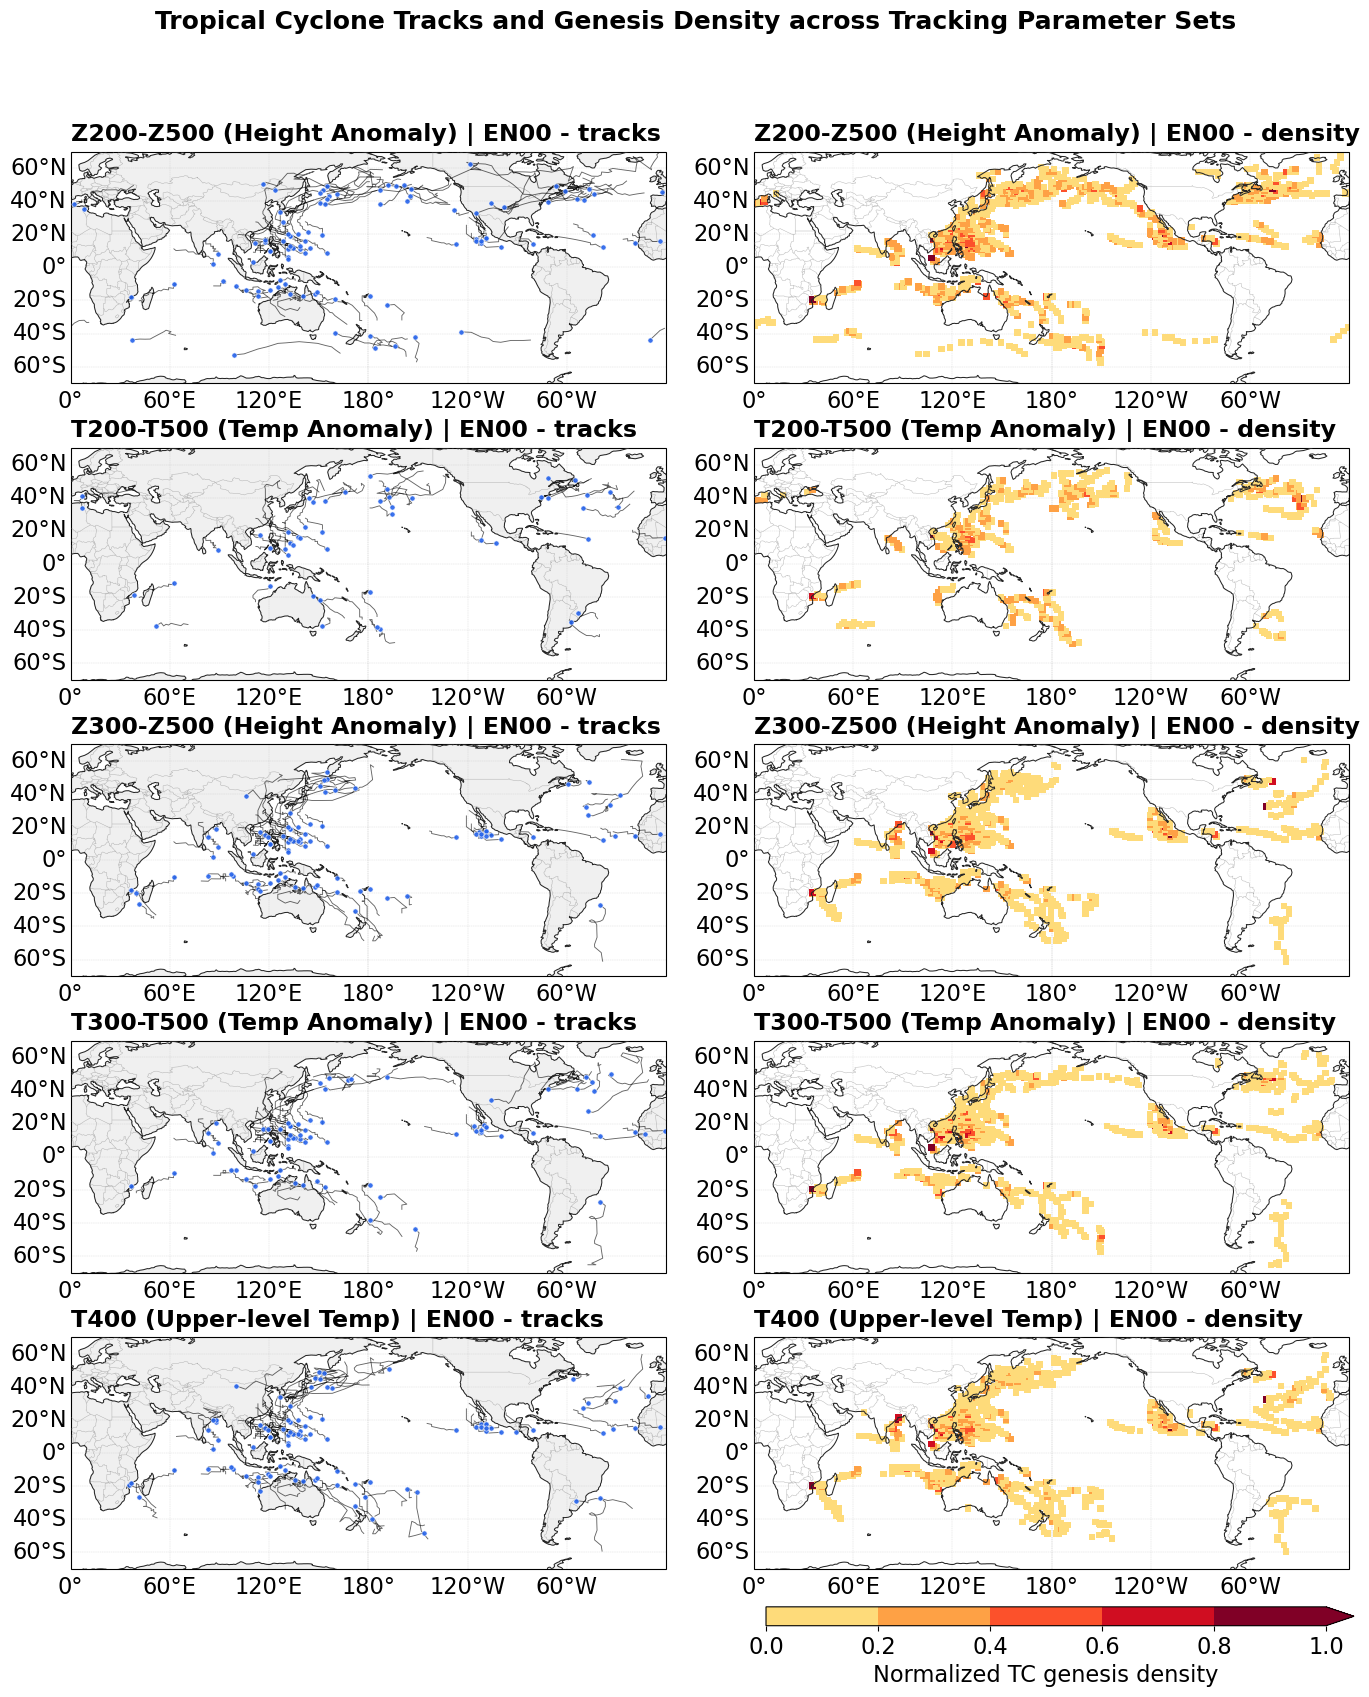

In [6]:
# Quick sanity plot: compare one HistogramNodes/Track pair for each tracking set
# -----------------------------
# Plot controls
# -----------------------------
QUICK_SANITY_PARSETS = ["set1", "set2", "set3", "set4", "set5"]
QUICK_SANITY_EXTENT = [0, 360, -70, 70]
QUICK_SANITY_CENTRAL_LONGITUDE = 180

QUICK_SANITY_FIG_TITLE = "Tropical Cyclone Tracks and Genesis Density across Tracking Parameter Sets"
QUICK_SANITY_FIG_WIDTH = 14.0
QUICK_SANITY_ROW_HEIGHT = 3.6
QUICK_SANITY_EXTRA_HEIGHT = 0.9
QUICK_SANITY_SUBPLOTS_ADJUST = dict(
    left=0.04, right=0.98, top=0.90, bottom=0.15, wspace=0.08, hspace=0.28
)

# Master font-size control
QUICK_SANITY_FONTSIZE = 18.0

# Automatically scaled font sizes
QUICK_SANITY_TITLE_FONTSIZE = 1.0 * QUICK_SANITY_FONTSIZE
QUICK_SANITY_PANEL_FONTSIZE = 0.95 * QUICK_SANITY_FONTSIZE
QUICK_SANITY_LABEL_FONTSIZE = 0.90 * QUICK_SANITY_FONTSIZE
QUICK_SANITY_TICK_FONTSIZE = 0.9 * QUICK_SANITY_FONTSIZE
QUICK_SANITY_ANNOTATION_FONTSIZE = 0.9 * QUICK_SANITY_FONTSIZE

QUICK_SANITY_CMAP_NAME = "YlOrRd"
QUICK_SANITY_CMAP_START = 0.24
QUICK_SANITY_COLOR_LEVELS = np.arange(0, 1.01, 0.2)
QUICK_SANITY_COLORBAR_TICKS = np.arange(0, 1.01, 0.2)
QUICK_SANITY_COLORBAR_LABEL = "Normalized TC genesis density"
QUICK_SANITY_COLORBAR_AX = [0.55, 0.12, 0.42, 0.01]
QUICK_SANITY_DENSITY_ALPHA = 1.0
QUICK_SANITY_NORMALIZE_DENSITY = True

# Sparse single-member density grids often have only a handful of nonzero
# cells; pcolormesh alone can render those as sub-pixel, effectively invisible
# marks.  A scatter overlay (sized independently of the histogram grid
# spacing) guarantees every nonzero cell is visible regardless of resolution.
QUICK_SANITY_DENSITY_MARKER_SIZE = 22
QUICK_SANITY_DENSITY_MARKER = "s"

QUICK_SANITY_COASTLINE_KW = dict(linewidth=0.75, color="0.15", zorder=3)
QUICK_SANITY_BORDER_KW = dict(linewidth=0.35, edgecolor="0.45", alpha=0.5, zorder=3)
QUICK_SANITY_GRIDLINE_KW = dict(linewidth=0.3, color="0.65", alpha=0.45, linestyle="--", zorder=3)
QUICK_SANITY_TRACK_KW = dict(colors="black", linewidths=0.65, alpha=0.6)
QUICK_SANITY_GENESIS_KW = dict(
    s=14, marker="o", color="#2563eb", edgecolor="white", linewidth=0.45, alpha=0.9
)

quick_panels = []
_quick_sanity_expected = len(CASES) * len(members_avail)

for pset in QUICK_SANITY_PARSETS:
    hist_files = []
    missing_pairs = []
    for case in CASES:
        for member in members_avail:
            analysis_dir = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis"
            hist_file = analysis_dir / f"{case}_{member}_{pset}_TCS_hist.nc"
            if hist_file.is_file():
                hist_files.append({"case": case, "member": member, "path": hist_file})
            else:
                missing_pairs.append((case, member))

    print(f"[{pset}] Found {len(hist_files)} of {_quick_sanity_expected} expected histogram files")
    if missing_pairs:
        preview = ", ".join(f"{c}/{m}" for c, m in missing_pairs[:5])
        more = "" if len(missing_pairs) <= 5 else f" ... ({len(missing_pairs) - 5} more)"
        print(f"[{pset}] Missing: {preview}{more}")

    if not hist_files:
        print(f"[{pset}] No histogram files found - skipping.")
        continue

    entry = hist_files[0]
    case, member, hist_file = entry["case"], entry["member"], entry["path"]
    analysis_dir = hist_file.parent
    track_file = analysis_dir / f"{case}_{member}_{pset}_TCS_track.txt"
    if not track_file.is_file():
        track_file = None

    with xr.open_dataset(hist_file) as ds_hist:
        # HistogramNodes always writes a 'density' variable; silently falling
        # back to an arbitrary variable could produce a scientifically
        # incorrect figure.
        if "density" not in ds_hist.data_vars:
            raise KeyError(
                f"Expected 'density' in {hist_file}; found {list(ds_hist.data_vars)}"
            )
        varname = "density"
        density = ds_hist[varname].sum(
            dim=[d for d in ds_hist[varname].dims if d not in ("lat", "lon")]
        ).load()

    lon2d, lat2d = np.meshgrid(density["lon"].values, density["lat"].values)

    land_mask = xr.DataArray(
        globe.is_land(lat2d, ((lon2d + 180.0) % 360.0) - 180.0),
        coords=density.coords,
        dims=density.dims,
    )

    plot_density = density.where((density > 0) & (~land_mask))
    land_points = float(density.where(land_mask).sum())
    max_density = float(plot_density.max(skipna=True))

    if QUICK_SANITY_NORMALIZE_DENSITY and np.isfinite(max_density) and max_density > 0:
        plot_density_for_plot = plot_density / max_density
    else:
        plot_density_for_plot = plot_density

    tracks = read_stitch_nodes_tracks([track_file]) if track_file is not None else pd.DataFrame()
    n_storms = (
        tracks[["case", "member", "storm_id"]].drop_duplicates().shape[0]
        if not tracks.empty
        else 0
    )

    n_nonzero_cells = int(((density > 0) & (~land_mask)).sum())
    print(f"[{pset}] Histogram: {hist_file}")
    print(f"[{pset}] Track    : {track_file if track_file is not None else 'not found'}")
    print(
        f"[{pset}] {varname!r}: total={float(density.sum()):.0f}, "
        f"land_points={land_points:.0f}, ocean nonzero cells={n_nonzero_cells}, "
        f"max={max_density:.0f}; tracks={n_storms}, points={len(tracks)}"
    )
    print(
        f"[{pset}] plotted density: nonzero={int(np.isfinite(plot_density_for_plot.values).sum())}, "
        f"min={float(plot_density_for_plot.min(skipna=True)):.3g}, "
        f"max={float(plot_density_for_plot.max(skipna=True)):.3g}"
    )
    if n_nonzero_cells == 0:
        print(
            f"[{pset}] WARNING: no nonzero ocean cells in {varname!r} — the density "
            f"panel will be blank.  Check that {hist_file.name} actually has track data."
        )

    quick_panels.append(
        {
            "pset": pset,
            "case": case,
            "member": member,
            "hist_file": hist_file,
            "track_file": track_file,
            "plot_density_for_plot": plot_density_for_plot,
            "max_density": max_density,
            "tracks": tracks,
        }
    )

if not quick_panels:
    print("No histogram files found for any quick sanity set - run Section 5 first.")
else:
    from cartopy.util import add_cyclic_point
    from matplotlib.colors import BoundaryNorm, ListedColormap

    levels = np.asarray(QUICK_SANITY_COLOR_LEVELS)
    base_cmap = plt.get_cmap(QUICK_SANITY_CMAP_NAME)
    # ListedColormap needs one color per bin, i.e. len(levels) - 1 colors for
    # len(levels) boundaries.  Previously this sampled len(levels) colors,
    # which desynchronized BoundaryNorm's bin-to-color mapping and could push
    # low-but-nonzero density values onto colors indistinguishable from white.
    cmap = ListedColormap(
        base_cmap(np.linspace(QUICK_SANITY_CMAP_START, 1.0, len(levels) - 1))
    )
    cmap.set_bad((1, 1, 1, 0))
    cmap.set_over(base_cmap(1.0))
    norm = BoundaryNorm(levels, cmap.N)

    def _setup_map_axis(ax, title):
        ax.set_extent(QUICK_SANITY_EXTENT, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
        ax.add_feature(cfeature.LAND, facecolor="0.94", zorder=0)
        ax.set_title(
            title,
            fontsize=QUICK_SANITY_PANEL_FONTSIZE,
            fontweight="bold",
            pad=8,
            loc="left",
        )
        ax.coastlines(**QUICK_SANITY_COASTLINE_KW)
        ax.add_feature(cfeature.BORDERS, **QUICK_SANITY_BORDER_KW)
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            **QUICK_SANITY_GRIDLINE_KW,
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": QUICK_SANITY_TICK_FONTSIZE}
        gl.ylabel_style = {"size": QUICK_SANITY_TICK_FONTSIZE}
        return gl

    def _plot_tracks(ax, tracks):
        if tracks.empty:
            ax.text(
                0.5,
                0.5,
                "no tracks",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=QUICK_SANITY_ANNOTATION_FONTSIZE,
                color="0.4",
            )
            return

        segments = []
        starts = []
        for _, storm in tracks.sort_values("time").groupby(["case", "member", "storm_id"]):
            points = storm[["lon", "lat"]].to_numpy()
            if len(points) < 2:
                continue
            starts.append(points[0])
            split_at = np.where(np.abs(np.diff(points[:, 0])) > 180.0)[0] + 1
            for segment in np.split(points, split_at):
                if len(segment) >= 2:
                    segments.append(segment)

        if segments:
            track_lines = LineCollection(
                segments,
                transform=ccrs.PlateCarree(),
                zorder=4,
                **QUICK_SANITY_TRACK_KW,
            )
            ax.add_collection(track_lines)

        if starts:
            starts = np.asarray(starts)
            ax.scatter(
                starts[:, 0], starts[:, 1],
                transform=ccrs.PlateCarree(),
                zorder=5,
                **QUICK_SANITY_GENESIS_KW,
            )

    nrows = len(quick_panels)
    fig, axes = plt.subplots(
        nrows,
        2,
        figsize=(QUICK_SANITY_FIG_WIDTH, QUICK_SANITY_ROW_HEIGHT * nrows + QUICK_SANITY_EXTRA_HEIGHT),
        subplot_kw={
            "projection": ccrs.PlateCarree(
                central_longitude=QUICK_SANITY_CENTRAL_LONGITUDE
            )
        },
        squeeze=False,
    )
    im = None

    for row, panel in enumerate(quick_panels):
        pset = panel["pset"]
        pset_display = PSET_DISPLAY_NAMES.get(pset, pset)
        label = f"{pset_display} | {panel['member']}"

        track_ax = axes[row, 0]
        density_ax = axes[row, 1]

        _setup_map_axis(track_ax, f"{label} - tracks")
        _plot_tracks(track_ax, panel["tracks"])

        _setup_map_axis(density_ax, f"{label} - density")
        density_da = panel["plot_density_for_plot"]
        has_density = (
            np.isfinite(panel["max_density"])
            and panel["max_density"] > 0
            and np.isfinite(density_da.values).any()
        )
        if has_density:
            density_values, density_lon = add_cyclic_point(
                density_da.values,
                coord=density_da["lon"].values,
                axis=1,
            )
            lon2d, lat2d = np.meshgrid(density_lon, density_da["lat"].values)
            im = density_ax.pcolormesh(
                lon2d,
                lat2d,
                density_values,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                norm=norm,
                shading="auto",
                alpha=QUICK_SANITY_DENSITY_ALPHA,
                zorder=1,
                rasterized=True,
            )

            # Guarantee every nonzero cell is visible even when the
            # HistogramNodes grid is coarse and a single member/case produces
            # only a handful of scattered nonzero cells (sub-pixel at map
            # scale for pcolormesh alone).
            lon_vals = density_da["lon"].values
            lat_vals = density_da["lat"].values
            lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
            values = density_da.values
            finite_mask = np.isfinite(values)
            if finite_mask.any():
                density_ax.scatter(
                    lon_grid[finite_mask],
                    lat_grid[finite_mask],
                    c=values[finite_mask],
                    cmap=cmap,
                    norm=norm,
                    transform=ccrs.PlateCarree(),
                    s=QUICK_SANITY_DENSITY_MARKER_SIZE,
                    marker=QUICK_SANITY_DENSITY_MARKER,
                    linewidths=0,
                    zorder=2,
                )
        else:
            density_ax.text(
                0.5,
                0.5,
                "no density data",
                transform=density_ax.transAxes,
                ha="center",
                va="center",
                fontsize=QUICK_SANITY_ANNOTATION_FONTSIZE,
                color="0.4",
            )

    fig.subplots_adjust(**QUICK_SANITY_SUBPLOTS_ADJUST)

    if im is not None:
        cbar_ax = fig.add_axes(QUICK_SANITY_COLORBAR_AX)
        cbar = fig.colorbar(
            im,
            cax=cbar_ax,
            orientation="horizontal",
            ticks=QUICK_SANITY_COLORBAR_TICKS,
            boundaries=levels,
            extend="max",
        )
        cbar.set_label(
            QUICK_SANITY_COLORBAR_LABEL,
            fontsize=QUICK_SANITY_LABEL_FONTSIZE,
        )
        cbar.ax.tick_params(labelsize=QUICK_SANITY_TICK_FONTSIZE)

    fig.suptitle(
        QUICK_SANITY_FIG_TITLE,
        fontsize=QUICK_SANITY_TITLE_FONTSIZE,
        fontweight="bold",
        y=0.975,
    )
    import esp_lab.utils.mov_utils as mov
    figname = figure_filename("tc_tracks_density_sanity_compare")
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(
        fig, figpath,
        mode="",
        metric="tc_tracks_density_sanity_compare",
        title="TC Tracks and Genesis Density Sensitivity Check",
        caption="Sensitivity of simulated TC tracks and genesis density to tracking configurations.",
        dpi=200,
    )
    print("Saved figure:", figpath)
    plt.show()



May initializations: 39 cases x 10 members
[May set1] Found 390 of 390 expected histogram files
[May set2] Found 390 of 390 expected histogram files
[May set3] Found 390 of 390 expected histogram files
[May set4] Found 390 of 390 expected histogram files
[May set5] Found 390 of 390 expected histogram files

November initializations: 39 cases x 10 members
[November set1] Found 390 of 390 expected histogram files
[November set2] Found 390 of 390 expected histogram files
[November set3] Found 390 of 390 expected histogram files
[November set4] Found 390 of 390 expected histogram files
[November set5] Found 390 of 390 expected histogram files


[May set1] Plotting mean 'density': total=1805.23, land-masked=229.42, ocean cells=10994, max_ocean=2.92


[November set1] Plotting mean 'density': total=1914.03, land-masked=234.74, ocean cells=11215, max_ocean=2.89


[May set2] Plotting mean 'density': total=968.50, land-masked=92.41, ocean cells=10453, max_ocean=1.07


[November set2] Plotting mean 'density': total=999.71, land-masked=91.79, ocean cells=10719, max_ocean=1.08


...

[May set4] Plotting mean 'density': total=1592.92, land-masked=154.25, ocean cells=10035, max_ocean=3.11


[November set4] Plotting mean 'density': total=1710.92, land-masked=160.19, ocean cells=10309, max_ocean=3.06


[May set5] Plotting mean 'density': total=1941.64, land-masked=212.57, ocean cells=10982, max_ocean=6.95


[November set5] Plotting mean 'density': total=2048.67, land-masked=211.39, ocean cells=11259, max_ocean=6.23


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_tc_genesis_density_method_compare.png


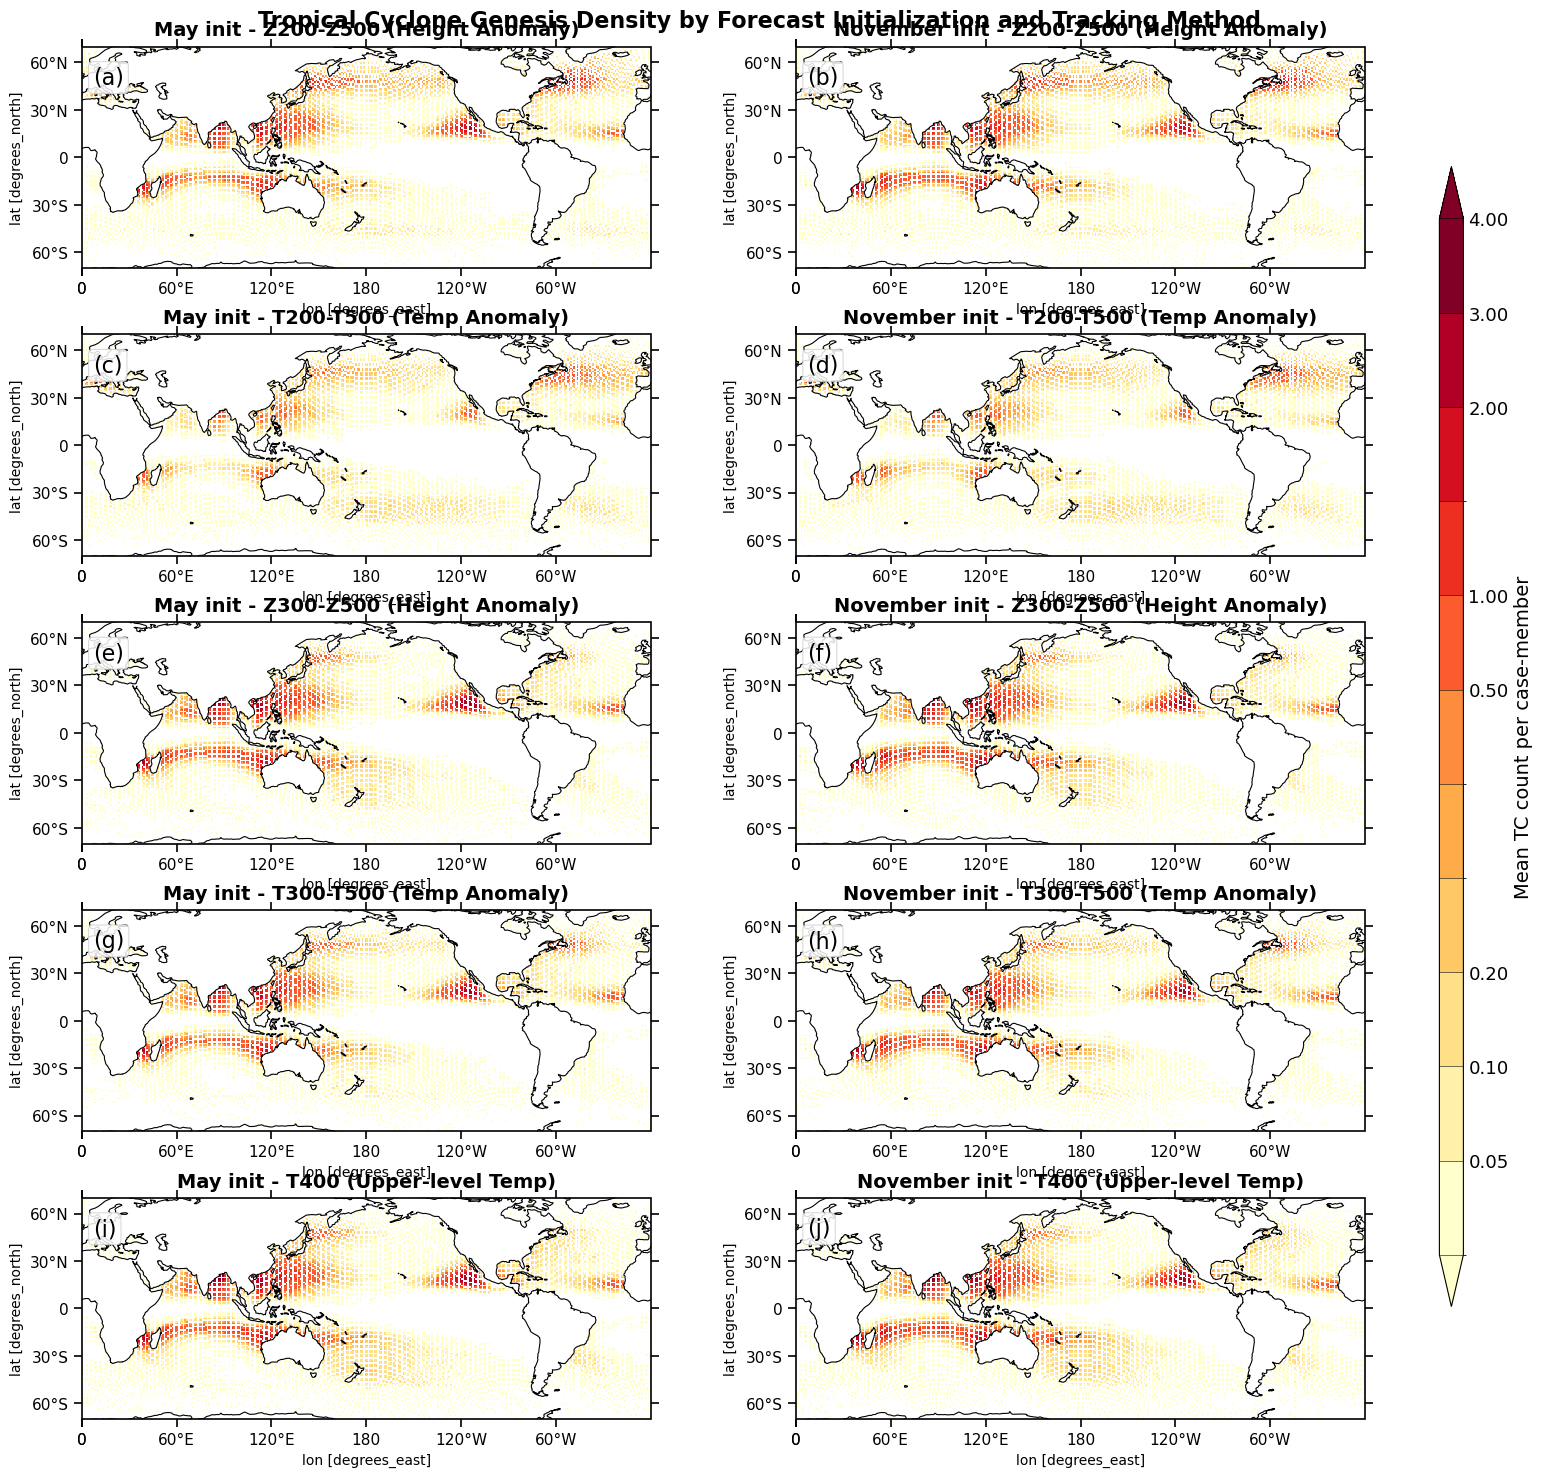

In [7]:
# Plot TC genesis density from HistogramNodes output by initialization month
parsets_to_plot = ["set1", "set2", "set3", "set4", "set5"]
init_months_to_plot = [5, 11]
init_month_labels = {5: "May", 11: "November"}


def _case_init_month(case):
    return int(str(case).rsplit("_", 1)[-1][4:6])


hist_files_by_init_and_pset = {}
for init_month in init_months_to_plot:
    init_label = init_month_labels.get(init_month, f"month {init_month:02d}")
    cases_for_init = [case for case in CASES if _case_init_month(case) == init_month]
    expected_per_pset = len(cases_for_init) * len(members_avail)
    hist_files_by_pset = {}

    print(f"\n{init_label} initializations: {len(cases_for_init)} cases x {len(members_avail)} members")
    for pset in parsets_to_plot:
        files_for_pset = []
        missing_pairs = []
        for case in cases_for_init:
            for member in members_avail:
                analysis_dir = TRACK_DIR / case / member / "post" / "atm" / "tc-analysis"
                hist_file = analysis_dir / f"{case}_{member}_{pset}_TCS_hist.nc"
                if hist_file.is_file():
                    files_for_pset.append(hist_file)
                else:
                    missing_pairs.append((case, member))

        print(f"[{init_label} {pset}] Found {len(files_for_pset)} of {expected_per_pset} expected histogram files")
        if missing_pairs:
            preview = ", ".join(f"{c}/{m}" for c, m in missing_pairs[:5])
            more = "" if len(missing_pairs) <= 5 else f" ... ({len(missing_pairs) - 5} more)"
            print(f"[{init_label} {pset}] Missing: {preview}{more}")

        hist_files_by_pset[pset] = files_for_pset

    hist_files_by_init_and_pset[init_month] = hist_files_by_pset

if not any(
    hist_files
    for files_by_pset in hist_files_by_init_and_pset.values()
    for hist_files in files_by_pset.values()
):
    print("No histogram files found for May or November initializations — run Section 5 first.")
else:
    n_rows = len(parsets_to_plot)
    n_cols = len(init_months_to_plot)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(8.0 * n_cols, 3.0 * n_rows),
        subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
        squeeze=False
    )

    levels = np.array([0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0])
    colorbar_ticks = [0.05, 0.1, 0.2, 0.5, 1, 2, 3, 4]
    cmap = plt.get_cmap("YlOrRd", len(levels) - 1).copy()
    cmap.set_bad((1, 1, 1, 0))
    im = None

    for row, pset in enumerate(parsets_to_plot):
        for col, init_month in enumerate(init_months_to_plot):
            init_label = init_month_labels.get(init_month, f"month {init_month:02d}")
            hist_files = hist_files_by_init_and_pset.get(init_month, {}).get(pset, [])
            ax = axes[row, col]

            ax.set_extent([0, 360, -70, 70], crs=ccrs.PlateCarree())

            xticks = np.arange(0, 361, 60)
            xtick_labels = ["0", "60°E", "120°E", "180", "120°W", "60°W", "0"]
            ax.set_xticks(xticks, crs=ccrs.PlateCarree())
            ax.set_xticklabels(xtick_labels, fontsize=11)
            ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
            ax.set_yticklabels(["60°S", "30°S", "0", "30°N", "60°N"], fontsize=11)

            ax.tick_params(axis="both", which="major", direction="out", length=6, width=1.2,
                           top=True, right=True, labeltop=False, labelright=False)
            for spine in ax.spines.values():
                spine.set_linewidth(1.2)
            ax.coastlines(linewidth=0.8, color="black")

            if not hist_files:
                ax.text(
                    0.5, 0.5, "no histogram files", transform=ax.transAxes,
                    ha="center", va="center", fontsize=14, color="0.35",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7", alpha=0.9),
                )
                continue

            ds_hist = xr.open_mfdataset(
                hist_files,
                combine="nested",
                concat_dim="hist_file",
                coords="minimal",
                compat="override",
                combine_attrs="override",
            )
            try:
                # HistogramNodes always writes a 'density' variable; silently
                # falling back to an arbitrary variable could produce a
                # scientifically incorrect figure.
                if "density" not in ds_hist.data_vars:
                    raise KeyError(
                        f"Expected 'density' in histogram files for {pset}; "
                        f"found {list(ds_hist.data_vars)}"
                    )
                density = ds_hist["density"]
                if "hist_file" in density.dims:
                    density = density.mean(dim="hist_file")
                extra_dims = [d for d in density.dims if d not in ("lat", "lon")]
                if extra_dims:
                    density = density.sum(dim=extra_dims)
                density = density.load()
            finally:
                ds_hist.close()

            lon2d, lat2d = np.meshgrid(density["lon"].values, density["lat"].values)
            land_mask = xr.DataArray(
                globe.is_land(lat2d, ((lon2d + 180.0) % 360.0) - 180.0),
                coords=density.coords,
                dims=density.dims,
            )
            land_points = float(density.where(land_mask).sum())
            plot_density = density.where((density > 0) & (~land_mask))
            print(
                f"[{init_label} {pset}] Plotting mean 'density': total={float(density.sum()):.2f}, "
                f"land-masked={land_points:.2f}, ocean cells={int(((density > 0) & (~land_mask)).sum())}, "
                f"max_ocean={float(plot_density.max(skipna=True)):.2f}"
            )

            im = plot_density.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                levels=levels,
                extend="both",
                add_colorbar=False,
            )
            pset_display = PSET_DISPLAY_NAMES.get(pset, pset)
            ax.set_title(f"{init_label} init - {pset_display}", fontsize=14, fontweight="bold", pad=8)

            letter = chr(ord('a') + row * n_cols + col)
            ax.text(
                0.02, 0.86, f"({letter})", transform=ax.transAxes,
                fontsize=16, ha="left", va="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8),
            )

    fig.subplots_adjust(left=0.055, right=0.90, top=0.96, bottom=0.045, hspace=0.30, wspace=0.12)
    if im is not None:
        cbar_ax = fig.add_axes([0.925, 0.12, 0.015, 0.76]) # [left, bottom, width, height]
        cbar = fig.colorbar(
            im, cax=cbar_ax, orientation="vertical",
            ticks=colorbar_ticks, drawedges=True,
        )
        cbar.set_label("Mean TC count per case-member", fontsize=14)
        cbar.ax.tick_params(labelsize=13, length=0)
    fig.suptitle("Tropical Cyclone Genesis Density by Forecast Initialization and Tracking Method", fontsize=16, fontweight="bold", y=0.985)
    import esp_lab.utils.mov_utils as mov
    figname = figure_filename("tc_genesis_density_method_compare")
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(
        fig, figpath,
        mode="",
        metric="tc_genesis_density_method_compare",
        title="TC Genesis Density Method Comparison",
        caption="Mean TC genesis density comparison by forecast initialization month and tracking method.",
        dpi=200,
    )
    print("Saved figure:", figpath)
    plt.show()


TC trajectory lead-year panels: 78 cases over 1980-2018 initializations


  IBTrACS Year 1: 3534 storms, 69737 points
  IBTrACS Year 2: 3552 storms, 69894 points


  set1 Year 1: 780 files, 3534 plotted / 35346 total tracks, 70740 points


  set1 Year 2: 780 files, 3552 plotted / 37478 total tracks, 71360 points


  set2 Year 1: 780 files, 3534 plotted / 23805 total tracks, 56225 points


...

  set4 Year 1: 780 files, 3534 plotted / 30418 total tracks, 72754 points


  set4 Year 2: 780 files, 3552 plotted / 31920 total tracks, 72401 points


  set5 Year 1: 780 files, 3534 plotted / 35606 total tracks, 76606 points


  set5 Year 2: 780 files, 3552 plotted / 36640 total tracks, 77319 points


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_tc_trajectory_compare_set3.png


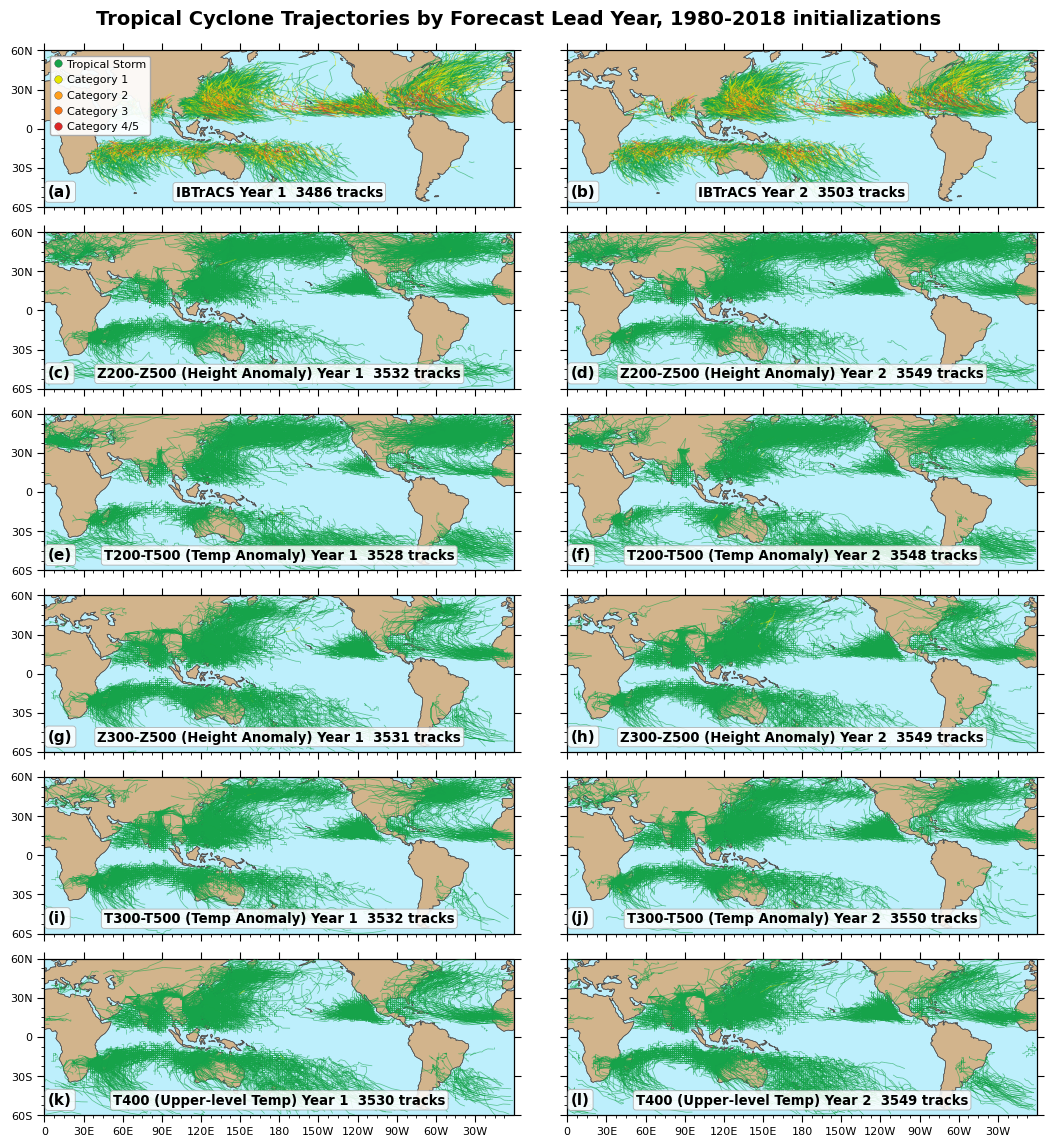

In [8]:
# Publication-style sanity plot: observed and method-set TC trajectories as stacked panels
sys.path.append(str(WORKFLOWS_DIR))

# -----------------------------
# User controls
# -----------------------------
TRACK_PANEL_CASES = globals().get("TRACK_PANEL_CASES", CASES)
TRACK_PANEL_START_YEAR = globals().get("TRACK_PANEL_START_YEAR", globals().get("years", None))
TRACK_PANEL_END_YEAR = globals().get("TRACK_PANEL_END_YEAR", globals().get("yeare", None))
TRACK_PANEL_WIND_SOURCE = globals().get("TRACK_PANEL_WIND_SOURCE", "wind")
TRACK_PANEL_MAX_TRACKS_PER_PANEL = globals().get("TRACK_PANEL_MAX_TRACKS_PER_PANEL", None)
TRACK_PANEL_MATCH_OBS_TRACK_COUNT = globals().get("TRACK_PANEL_MATCH_OBS_TRACK_COUNT", True)
TRACK_PANEL_RANDOM_SEED = globals().get("TRACK_PANEL_RANDOM_SEED", 42)

# Match the example figure's 30E-to-0 view, with a Pacific-centered projection.
TRACK_PANEL_EXTENT = globals().get("TRACK_PANEL_EXTENT", [30, 360, -60, 60])
TRACK_PANEL_CENTRAL_LONGITUDE = globals().get("TRACK_PANEL_CENTRAL_LONGITUDE", 180)

# IBTrACS filtering. Set OBS_WIND_MIN_KT = None before this cell to include weaker points.
ibtracs_default = Path(
    "/global/cfs/cdirs/e3sm/zhan391/TempestExtremes/OBS/tc_track/"
    "IBTrACS/IBTrACS.since1980.v04r00.nc"
)
IBTRACS_TRACK_FILE = Path(globals().get("IBTRACS_FILE", ibtracs_default))
OBS_WIND_MIN_KT_FOR_TRACKS = globals().get("OBS_WIND_MIN_KT", 34.0)
OBS_TIME_STEP_HOURS_FOR_TRACKS = globals().get("OBS_TIME_STEP_HOURS", 6)

# Saffir-Simpson category thresholds in knots.
# Tropical Storm is 34-63 kt; Categories 4 and 5 are combined to match the reference style.
TC_CATEGORIES = [
    ("Tropical Storm", 34.0, 64.0, "#16a34a"),
    ("Category 1", 64.0, 83.0, "#e6e600"),
    ("Category 2", 83.0, 96.0, "#ff9f1c"),
    ("Category 3", 96.0, 113.0, "#f97316"),
    ("Category 4/5", 113.0, np.inf, "#dc2626"),
]


def _case_year(case_name):
    match = re.search(r"_(\d{10})$", str(case_name))
    return int(match.group(1)[:4]) if match else None


def _filter_cases_by_year(cases, start_year=None, end_year=None):
    selected = []
    for case in cases:
        year = _case_year(case)
        if start_year is not None and year is not None and year < start_year:
            continue
        if end_year is not None and year is not None and year > end_year:
            continue
        selected.append(case)
    return selected


def _read_ibtracs_tracks(path, start_year=None, end_year=None, wind_min_kt=34.0, time_step_hours=6):
    """Return an IBTrACS point table for trajectory plotting."""
    ds_obs = xr.open_dataset(path)
    wind = xr.where(np.isfinite(ds_obs["wmo_wind"]), ds_obs["wmo_wind"], ds_obs["usa_wind"])

    lat_da = ds_obs["lat"]
    storm_dim, point_dim = lat_da.dims[:2]
    storm_id = np.repeat(np.arange(lat_da.sizes[storm_dim]), lat_da.sizes[point_dim])

    lat = lat_da.values.ravel()
    lon = ds_obs["lon"].values.ravel() % 360.0
    time = pd.to_datetime(ds_obs["time"].values.ravel())
    wind_kt = wind.values.ravel()

    valid = ~pd.isna(time) & np.isfinite(lat) & np.isfinite(lon)
    if wind_min_kt is not None:
        valid &= np.isfinite(wind_kt) & (wind_kt >= wind_min_kt)

    obs = pd.DataFrame({
        "storm_id": storm_id[valid],
        "time": time[valid],
        "lat": lat[valid],
        "lon": lon[valid],
        "wind_kt": wind_kt[valid],
    })

    if time_step_hours is not None and not obs.empty:
        obs = obs[
            obs["time"].dt.minute.eq(0)
            & obs["time"].dt.second.eq(0)
            & obs["time"].dt.hour.mod(time_step_hours).eq(0)
        ].copy()

    if start_year is not None and not obs.empty:
        obs = obs[obs["time"].dt.year >= start_year].copy()
    if end_year is not None and not obs.empty:
        obs = obs[obs["time"].dt.year <= end_year].copy()

    return obs


def _infer_model_wind_kt(df, wind_col="wind"):
    """Convert model wind to kt; TempestExtremes runner writes m/s for this column."""
    wind = pd.to_numeric(df[wind_col], errors="coerce")
    if wind.dropna().empty:
        return wind

    # The runner threshold is configured in m/s. If a future file is already in kt,
    # avoid double conversion by checking the upper distribution.
    p99 = float(wind.quantile(0.99))
    return wind * 1.943844492 if p99 < 90.0 else wind


def _category_color(wind_kt, include_weak_as_ts=False):
    if not np.isfinite(wind_kt):
        return None
    if include_weak_as_ts and wind_kt < TC_CATEGORIES[1][1]:
        return TC_CATEGORIES[0][3]
    for _, lo, hi, color in TC_CATEGORIES:
        if lo <= wind_kt < hi:
            return color
    return None


def _thin_tracks(df, group_cols, max_tracks=None, random_seed=42):
    if max_tracks is None or df.empty:
        return df

    keys = df[group_cols].drop_duplicates()
    if len(keys) <= max_tracks:
        return df

    sampled = keys.sample(n=max_tracks, random_state=random_seed)
    return df.merge(sampled, on=group_cols, how="inner")


def _plot_category_tracks(ax, df, group_cols, wind_col="wind_kt", include_weak_as_ts=False):
    if df.empty:
        ax.text(0.5, 0.5, "no tracks", transform=ax.transAxes, ha="center", va="center", fontsize=11)
        return 0, 0

    n_tracks = 0
    n_segments = 0
    for _, group in df.sort_values("time").groupby(group_cols):
        group = group.dropna(subset=["lon", "lat", wind_col])
        if len(group) < 2:
            continue

        points = group[["lon", "lat"]].to_numpy(dtype=float)
        winds = group[wind_col].to_numpy(dtype=float)
        segments_by_color = {}

        for i in range(len(points) - 1):
            lon0, lat0 = points[i]
            lon1, lat1 = points[i + 1]
            if not np.all(np.isfinite([lon0, lat0, lon1, lat1])):
                continue
            if (lat0 < -60.0 or lat0 > 60.0 or lat1 < -60.0 or lat1 > 60.0):
                continue

            # Do not draw long wraparound lines across the map boundary.
            if abs(lon1 - lon0) > 180.0:
                continue

            color = _category_color(np.nanmax([winds[i], winds[i + 1]]), include_weak_as_ts=include_weak_as_ts)
            if color is None:
                continue

            segments_by_color.setdefault(color, []).append([(lon0, lat0), (lon1, lat1)])
            n_segments += 1

        for color, segments in segments_by_color.items():
            collection = LineCollection(
                segments,
                colors=color,
                linewidths=0.55,
                alpha=0.58,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )
            ax.add_collection(collection)

        n_tracks += 1

    if n_segments == 0:
        ax.text(0.5, 0.5, "no categorized segments", transform=ax.transAxes, ha="center", va="center", fontsize=11)

    return n_tracks, n_segments


def _format_track_axis(ax, panel_label, title, row, col, n_rows, n_cols):
    ax.set_extent(TRACK_PANEL_EXTENT, crs=ccrs.PlateCarree())
    ax.set_facecolor("#bdeffc")
    ax.add_feature(cfeature.LAND.with_scale("110m"), facecolor="#d2b48c", edgecolor="0.35", linewidth=0.45, zorder=1)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.45, edgecolor="0.30", zorder=2)

    xticks = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360]
    xtick_labels = ["30E", "60E", "90E", "120E", "150E", "180", "150W", "120W", "90W", "60W", "30W", "0"]
    yticks = [-60, -30, 0, 30, 60]
    ytick_labels = ["60S", "30S", "0", "30N", "60N"]

    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    if row == n_rows - 1:
        ax.set_xticklabels(xtick_labels, fontsize=8)
    else:
        ax.set_xticklabels([], fontsize=8)
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if col == 0:
        ax.set_yticklabels(ytick_labels, fontsize=8)
    else:
        ax.set_yticklabels([], fontsize=8)
    ax.tick_params(axis="both", which="major", direction="out", length=5, width=0.8, top=True, right=True)
    ax.minorticks_on()

    bbox = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.65", alpha=0.85, linewidth=0.6)
    ax.text(0.008, 0.05, panel_label, transform=ax.transAxes, fontsize=11, fontweight="bold", ha="left", va="bottom", bbox=bbox, zorder=12)
    ax.text(0.5, 0.05, title, transform=ax.transAxes, fontsize=9.5, fontweight="bold", ha="center", va="bottom", bbox=bbox, zorder=12)

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)


def _case_init_time(case_name):
    match = re.search(r"_(\d{10})$", str(case_name))
    return pd.to_datetime(match.group(1), format="%Y%m%d%H") if match else pd.NaT


def _filter_model_by_lead_year(df, lead_year):
    if df.empty:
        return df
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out["init_time"] = pd.to_datetime(out["init_time"])
    start = out["init_time"] + pd.DateOffset(years=lead_year - 1)
    end = out["init_time"] + pd.DateOffset(years=lead_year)
    return out[(out["time"] >= start) & (out["time"] < end)].copy()


def _filter_obs_to_verifying_windows(obs, cases, lead_year):
    if obs.empty:
        return obs
    keep = np.zeros(len(obs), dtype=bool)
    obs_time = pd.to_datetime(obs["time"])
    for case in cases:
        init_time = _case_init_time(case)
        if pd.isna(init_time):
            continue
        start = init_time + pd.DateOffset(years=lead_year - 1)
        end = init_time + pd.DateOffset(years=lead_year)
        keep |= ((obs_time >= start) & (obs_time < end)).to_numpy()
    return obs.loc[keep].copy()


selected_cases = _filter_cases_by_year(TRACK_PANEL_CASES, TRACK_PANEL_START_YEAR, TRACK_PANEL_END_YEAR)
if not selected_cases:
    raise ValueError("No TRACK_PANEL_CASES remain after year filtering.")

track_year_label = (
    f"{TRACK_PANEL_START_YEAR}-{TRACK_PANEL_END_YEAR} initializations"
    if TRACK_PANEL_START_YEAR is not None and TRACK_PANEL_END_YEAR is not None
    else "selected initializations"
)
print(f"TC trajectory lead-year panels: {len(selected_cases)} cases over {track_year_label}")

lead_years_to_plot = [1, 2]
lead_year_labels = {1: "Year 1", 2: "Year 2"}

parsets_to_plot = sorted({
    match.group(1)
    for case in selected_cases
    for path in (TRACK_DIR / case).glob("EN*/post/atm/tc-analysis/*_set*_TCS_track.txt")
    for match in [re.search(r"_(set\d+)_TCS_track\.txt$", path.name)]
    if match
})
if not parsets_to_plot:
    parsets_to_plot = ["set1", "set2", "set3", "set4", "set5"]

obs_by_lead = {}
obs_track_count_by_lead = {}
if IBTRACS_TRACK_FILE.exists():
    obs_all = _read_ibtracs_tracks(
        IBTRACS_TRACK_FILE,
        start_year=TRACK_PANEL_START_YEAR,
        end_year=None if TRACK_PANEL_END_YEAR is None else TRACK_PANEL_END_YEAR + max(lead_years_to_plot),
        wind_min_kt=OBS_WIND_MIN_KT_FOR_TRACKS,
        time_step_hours=OBS_TIME_STEP_HOURS_FOR_TRACKS,
    )
    for lead_year in lead_years_to_plot:
        obs_df = _filter_obs_to_verifying_windows(obs_all, selected_cases, lead_year)
        obs_df = _thin_tracks(obs_df, ["storm_id"], TRACK_PANEL_MAX_TRACKS_PER_PANEL, TRACK_PANEL_RANDOM_SEED + lead_year)
        n_obs = obs_df["storm_id"].nunique() if not obs_df.empty else 0
        obs_by_lead[lead_year] = obs_df
        obs_track_count_by_lead[lead_year] = n_obs
        print(f"  IBTrACS {lead_year_labels[lead_year]}: {n_obs} storms, {len(obs_df)} points")
else:
    print(f"  IBTrACS skipped; file not found: {IBTRACS_TRACK_FILE}")

model_by_pset_and_lead = {}
for pset in parsets_to_plot:
    t_files = []
    for case in selected_cases:
        t_files.extend(sorted((TRACK_DIR / case).glob(f"EN*/post/atm/tc-analysis/*_{pset}_TCS_track.txt")))

    df_all = read_stitch_nodes_tracks(t_files) if t_files else pd.DataFrame()
    if not df_all.empty:
        df_all = df_all.copy()
        df_all["wind_kt"] = _infer_model_wind_kt(df_all, TRACK_PANEL_WIND_SOURCE)

    model_by_pset_and_lead[pset] = {}
    for lead_year in lead_years_to_plot:
        df = _filter_model_by_lead_year(df_all, lead_year)
        n_tracks_total = df[["case", "member", "storm_id"]].drop_duplicates().shape[0] if not df.empty else 0
        if not df.empty:
            max_tracks = TRACK_PANEL_MAX_TRACKS_PER_PANEL
            obs_n_tracks = obs_track_count_by_lead.get(lead_year, 0)
            if TRACK_PANEL_MATCH_OBS_TRACK_COUNT and obs_n_tracks > 0:
                max_tracks = obs_n_tracks if max_tracks is None else min(max_tracks, obs_n_tracks)
            df = _thin_tracks(df, ["case", "member", "storm_id"], max_tracks, TRACK_PANEL_RANDOM_SEED + lead_year)
        model_by_pset_and_lead[pset][lead_year] = df
        n_tracks = df[["case", "member", "storm_id"]].drop_duplicates().shape[0] if not df.empty else 0
        print(f"  {pset} {lead_year_labels[lead_year]}: {len(t_files)} files, {n_tracks} plotted / {n_tracks_total} total tracks, {len(df)} points")

row_specs = [{"name": "IBTrACS", "kind": "obs"}] + [
    {"name": pset, "kind": "model", "pset": pset} for pset in parsets_to_plot
]
n_rows = len(row_specs)
n_cols = len(lead_years_to_plot)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.6 * n_cols, max(1.95 * n_rows, 3.0)),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=TRACK_PANEL_CENTRAL_LONGITUDE)},
    squeeze=False,
)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="None", markersize=5.5, markerfacecolor=color,
           markeredgecolor="0.25", markeredgewidth=0.25, label=label)
    for label, _, _, color in TC_CATEGORIES
]

for row, spec in enumerate(row_specs):
    for col, lead_year in enumerate(lead_years_to_plot):
        ax = axes[row, col]
        if spec["kind"] == "obs":
            df = obs_by_lead.get(lead_year, pd.DataFrame())
            group_cols = ["storm_id"]
            include_weak_as_ts = False
        else:
            df = model_by_pset_and_lead.get(spec["pset"], {}).get(lead_year, pd.DataFrame())
            group_cols = ["case", "member", "storm_id"]
            include_weak_as_ts = True

        n_tracks, n_segments = _plot_category_tracks(
            ax,
            df,
            group_cols,
            include_weak_as_ts=include_weak_as_ts,
        )
        panel_label = f"({chr(97 + row * n_cols + col)})"
        pset_display = PSET_DISPLAY_NAMES.get(spec['name'], spec['name'])
        title = f"{pset_display} {lead_year_labels[lead_year]}  {n_tracks} tracks"
        _format_track_axis(ax, panel_label, title, row, col, n_rows, n_cols)
        if row == 0 and col == 0:
            ax.legend(
                handles=legend_handles,
                loc="upper left",
                frameon=True,
                framealpha=0.92,
                facecolor="white",
                edgecolor="0.65",
                fontsize=8,
                borderpad=0.3,
                handlelength=0.9,
                handletextpad=0.35,
            )

fig.suptitle(f"Tropical Cyclone Trajectories by Forecast Lead Year, {track_year_label}", fontsize=14, fontweight="bold", y=0.985)
fig.subplots_adjust(left=0.06, right=0.98, top=0.95, bottom=0.04, hspace=0.16, wspace=0.03)
import esp_lab.utils.mov_utils as mov
figname = figure_filename("tc_trajectory_compare", PARSET)
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="tc_trajectory_compare",
    title="TC Trajectory Tracking Method Comparison",
    caption=f"Comparison of observed and model-simulated TC tracks for parset {PARSET}",
    dpi=200,
)
print("Saved figure:", figpath)
plt.show()
